# Legacy versus double-HG event display
Select one energy and one scattering length. The same event is displayed with the legacy model on the left and double-HG on the right. The display follows `global_fit_display`: 10 mm charge cells, black fit-selected fibres, green MC truth, and the red GlobalFit line.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import display
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'double_hg_event_comparison_tools.py').exists():
    NOTEBOOK_DIR = Path('/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/GlobalFitTest')
sys.path.insert(0, str(NOTEBOOK_DIR))
from double_hg_event_comparison_tools import *
plt.rcParams.update({'figure.dpi': 110})

## Select the matched pair
The available common scattering lengths are discovered automatically. Change `ENERGY` and `SCATTER_LENGTH_MM`, then rerun from this cell downward.

In [2]:
ENERGY = '5GeV'  # or '5GeV 0p7GeV'
SCATTER_LENGTH_MM = 0.7
BASE = Path('/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie') / ENERGY / 'maps'
pairs = discover_pairs(BASE)
print('Matched scattering lengths [mm]:', list(pairs))
runs, truth = load_pair(BASE, SCATTER_LENGTH_MM)
events = common_events(runs)
display(pd.DataFrame([{'model': label, 'scatter_length_mm': run['scatter'], 'events': run['fit'].event.nunique(), 'file': str(run['path'])} for label, run in runs.items()]))
print(f'{len(events)} common events: {events[0]}..{events[-1]}')

Matched scattering lengths [mm]: [0.25, 0.4, 0.7, 1.0]
Loading Legacy: /home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie/5GeV/maps/10bin_5m_0p7mm_100kPhotons/global_fit.root
Loading Double-HG: /home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie/5GeV/maps/10bin_5m_double_hg_0p7mm_g-0p5_rfb-0p75_fibre-1p0mm_scin-ri-1p48_100kPhotons/global_fit.root


,model,scatter_length_mm,events,file
0,Legacy,0.7,1000,/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/...
1,Double-HG,0.7,1000,/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/...


1000 common events: 0..999


## Synchronized display
Move one event control to update both models. A negative threshold uses the charge cut stored by each fit. Both models use the same fixed colour range of 1–150 PE.

In [3]:
interactive_pair(runs, truth);

Output()

### Widget-free fallback
Use this cell if the notebook frontend reports `model not found`.

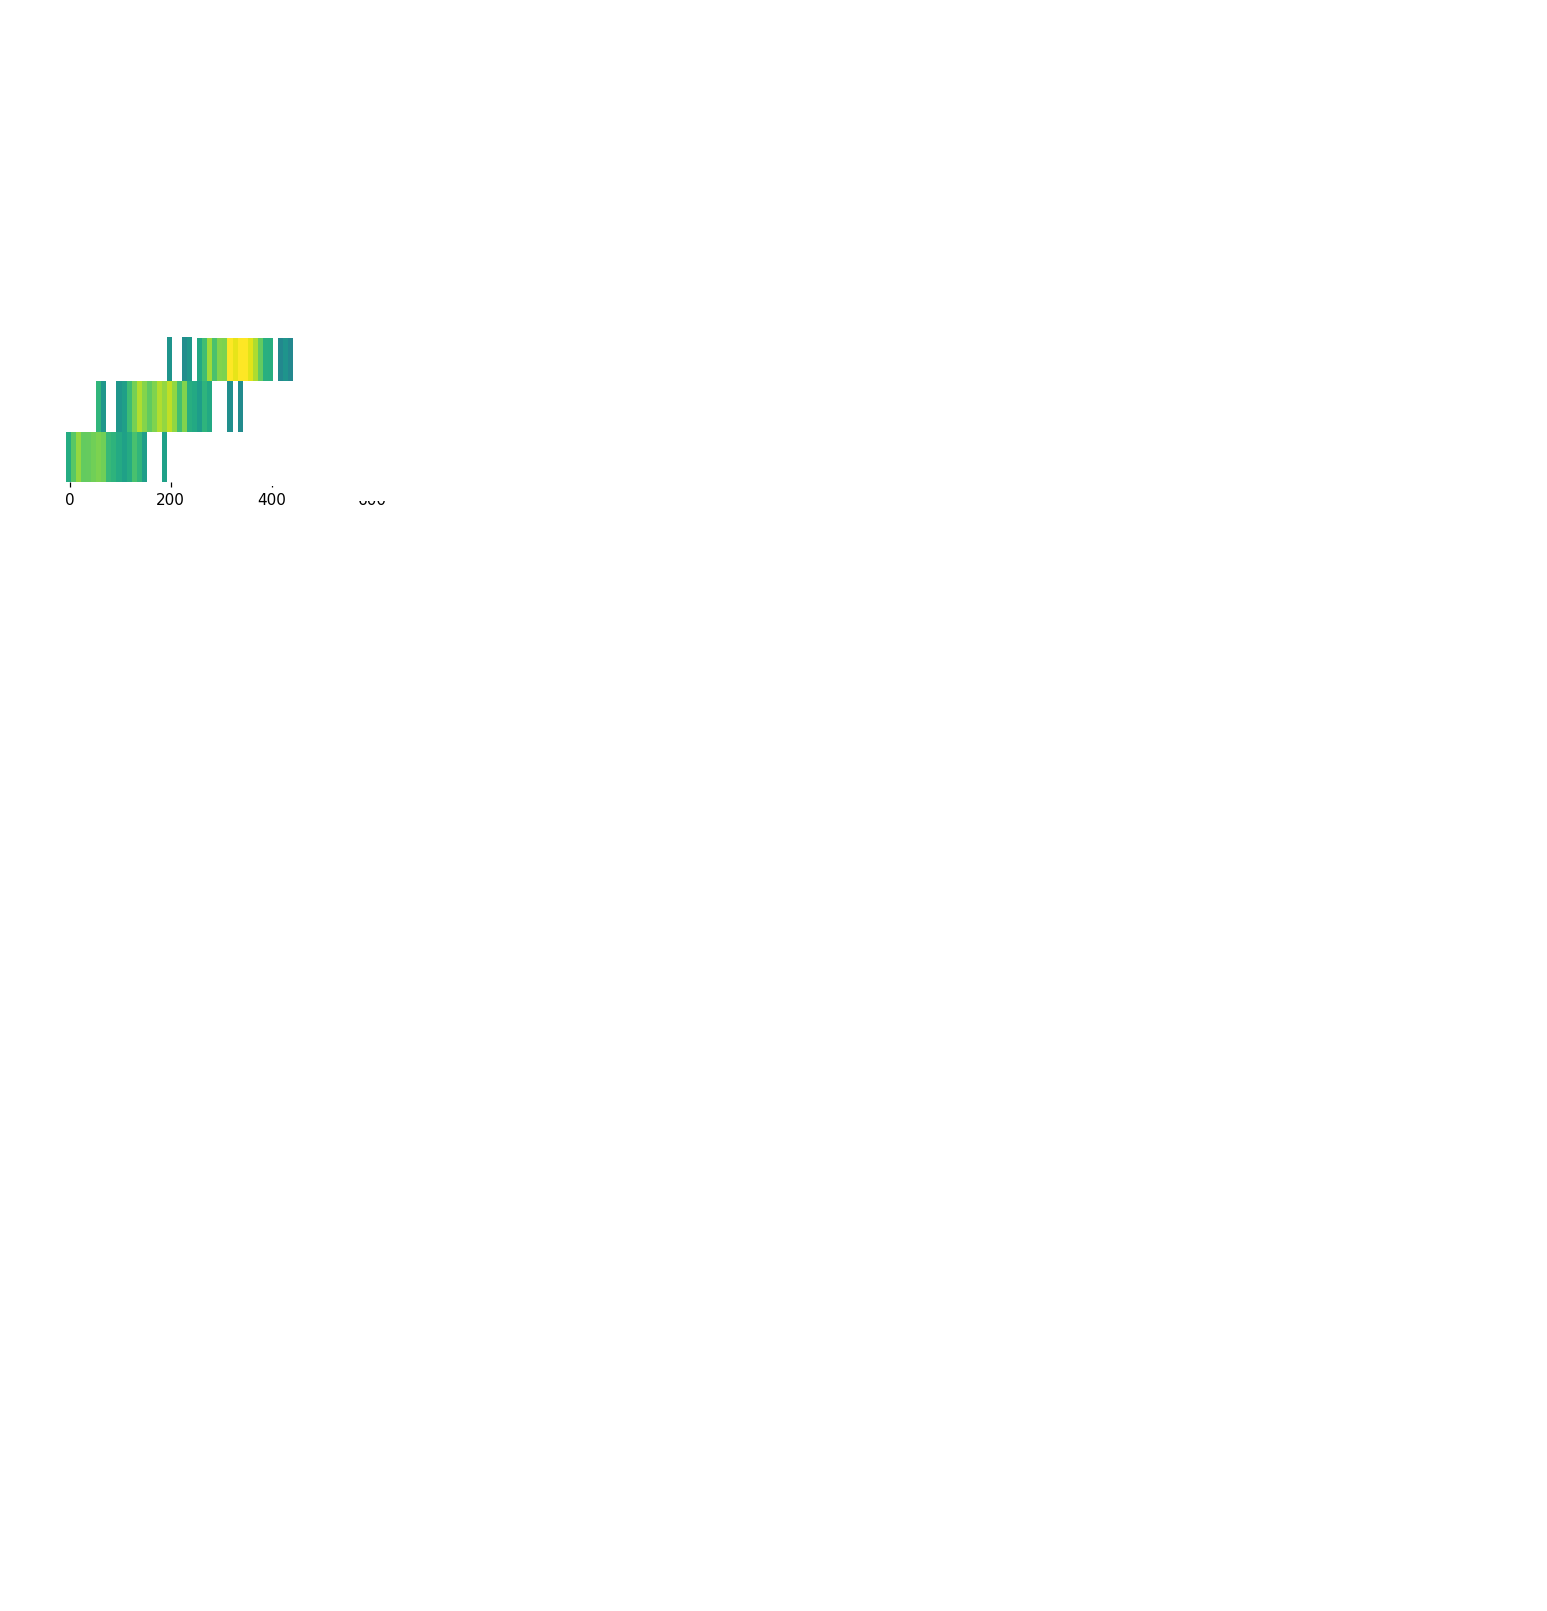

In [4]:
EVENT = events[0]
THRESHOLD = None  # None uses each fit's stored minimum_charge
draw_paired_event(runs, truth, EVENT, threshold=THRESHOLD, log_charge=True, show_mc=True, show_fit=True, show_selected=True, shared_charge_scale=False);

## Input-response controls

In [5]:
event_controls, input_figure = plot_input_controls(runs)
display(event_controls.groupby('model')[['hit_count','total_charge','maximum_charge']].agg(['mean','std','median']))

hit_count                    total_charge               \
               mean        std median          mean          std   
model                                                              
Double-HG   692.136  81.653480  667.0  16990.778775  3386.302062   
Legacy      646.899  77.977903  623.0  15785.460704  3137.422258   

                        maximum_charge                          
                 median           mean         std      median  
model                                                           
Double-HG  16038.408342     661.614508  249.165885  590.675690  
Legacy     14887.505030     647.884878  246.188194  580.797516

## GlobalFit controls

/home/tlux/venvs/jupyter/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


,events,status0_fraction,median_edm,median_chi2_ndof,median_seed_fit_angle_deg
model,,,,,
Double-HG,1000,0.0,0.008616,10.909006,5.045337
Legacy,1000,0.0,NaN,28.253363,3.145426


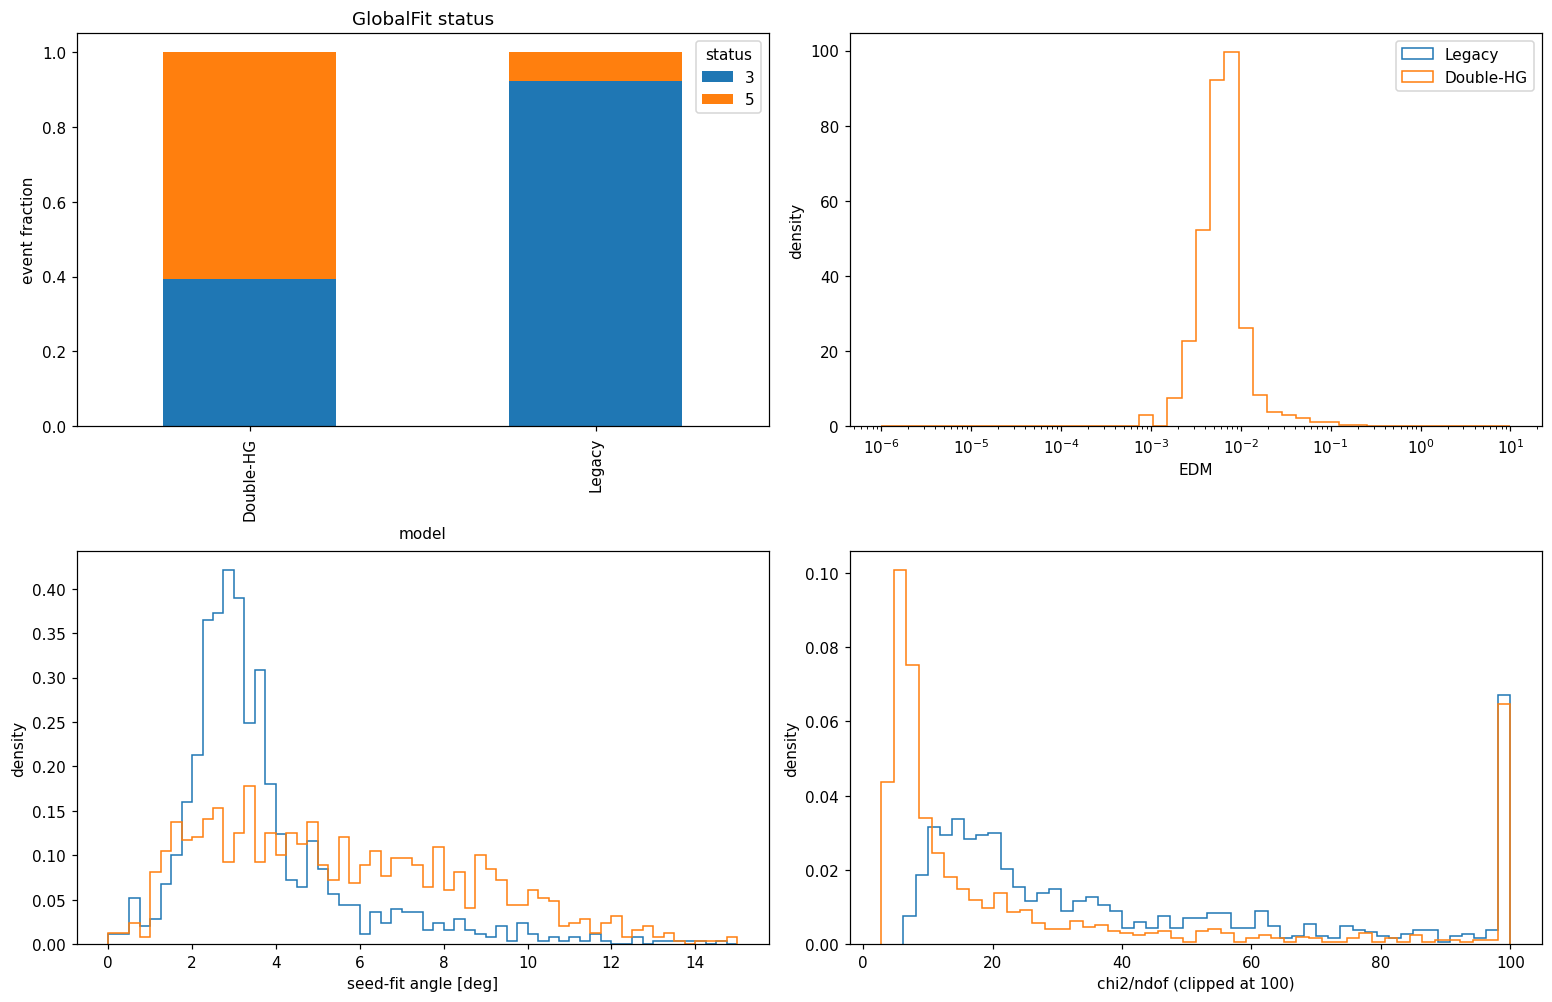

In [6]:
fit_controls, fit_figure = plot_fit_controls(runs)
display(fit_controls.groupby('model').agg(events=('event','nunique'), status0_fraction=('status',lambda x:(x==0).mean()), median_edm=('edm','median'), median_chi2_ndof=('chi2_ndof','median'), median_seed_fit_angle_deg=('seed_fit_angle_deg','median')))